<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5217: Natural Language Processing</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 4: Neural Machine Translation</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Neural Machine Translation (NMT) & Sequence-to-Sequence (Seq2Seq)**

**Neural Machine Translation (NMT)** is an approach to machine translation that uses a single neural network to translate an entire sentence from one language to another. Unlike older statistical methods that required manual alignment of words between languages, NMT learns to translate end-to-end directly from data.

The neural network architecture used for NMT is called **sequence-to-sequence(seq2seq)** and it involves **two RNNs** working together:

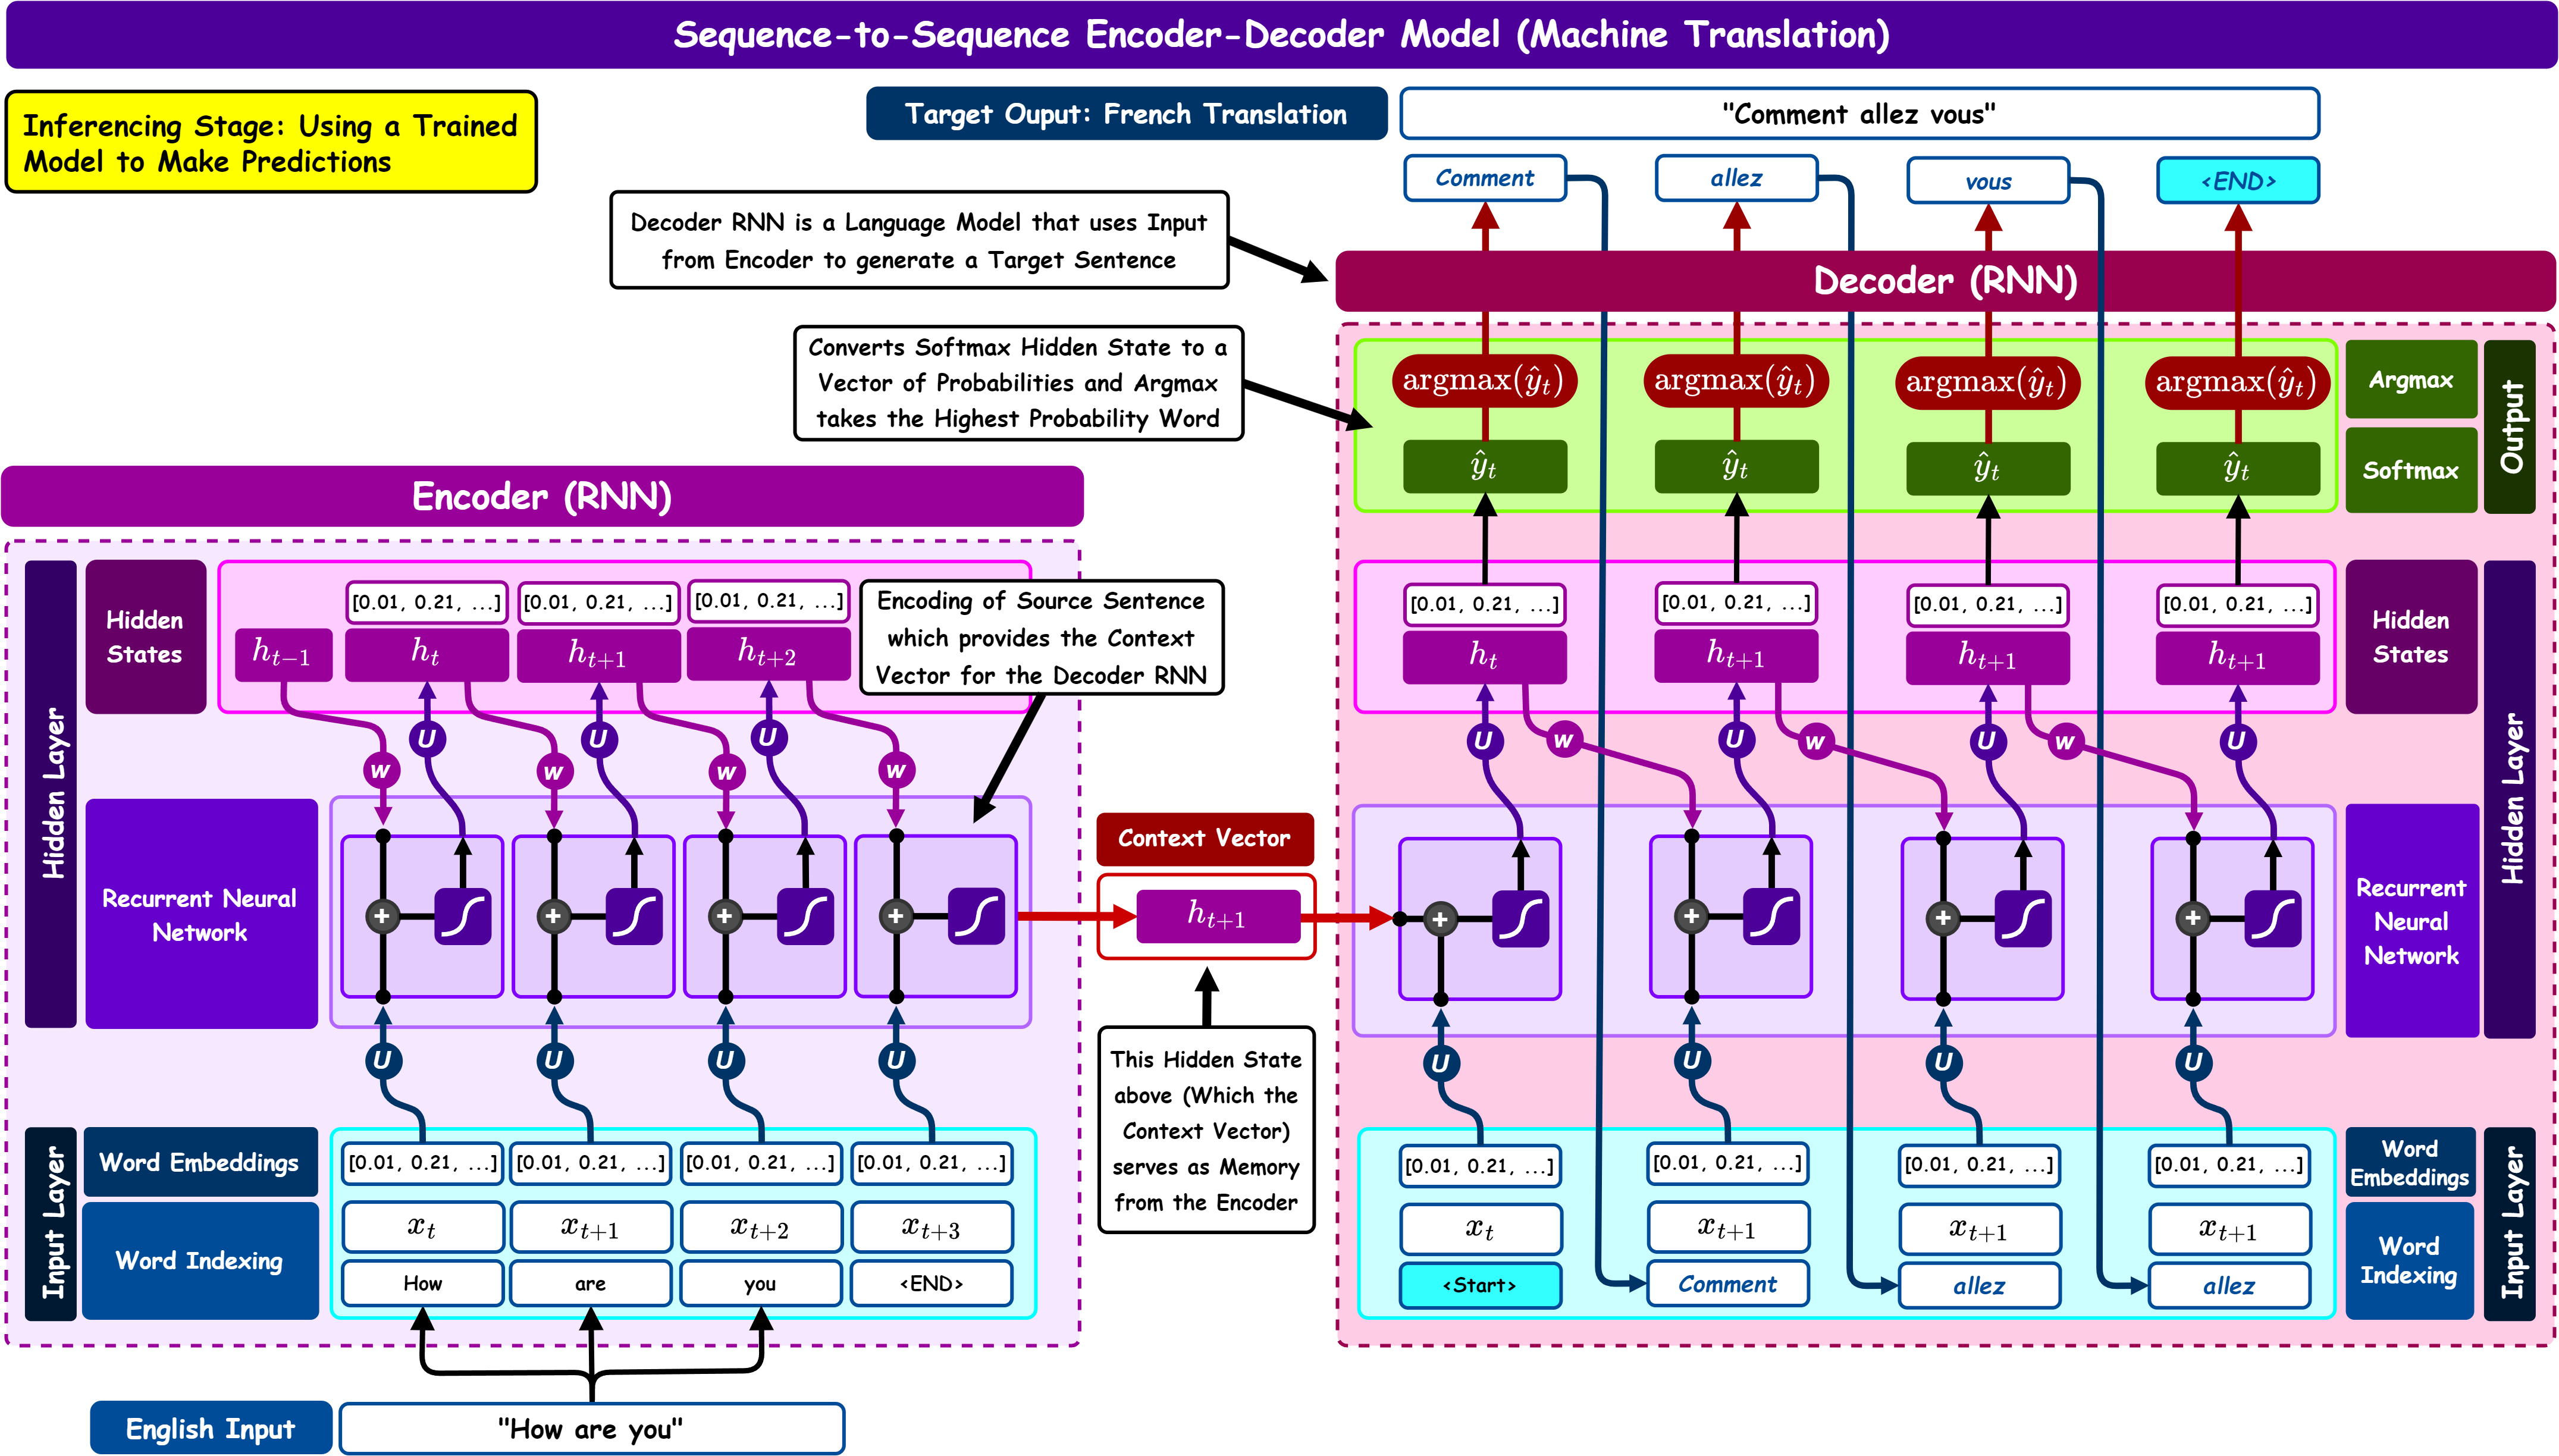


| Recurrent Neural Network | Name | Role |
|---|---|---|
| First RNN | **Encoder** | Reads the source sentence word by word and compresses it into a single context vector |
| Second RNN | **Decoder** | Takes the context vector and generates the translated sentence word by word |

The context vector is essentially the encoder's **final hidden state**, it carries the compressed meaning of the entire source sentence and passes it to the decoder as its starting hidden state $h_0$.


### **Seq2Seq as a Conditional Language Model**

The seq2seq model is an example of a **Conditional Language Model**:

- **Language Model** — because the decoder is predicting the next word of the target sentence $y$, just like a regular RNN language model
- **Conditional** — because its predictions are *also* conditioned on the source sentence $x$, it is not just predicting any next word, it is predicting the next word **of the translation**

**NMT directly calculates $P(y|x)$** the probability of the entire target sentence $y$ given the source sentence $x$:

$$P(y|x) = P(y_1|x) \cdot P(y_2|y_1, x) \cdot P(y_3|y_1, y_2, x) \cdots P(y_T|y_1, y_2, \ldots, y_{T-1}, x)$$

Where each term is the probability of the next target word, given all the target words generated so far **and** the source sentence $x$. The decoder generates the translation one word at a time, always conditioning on both what it has already produced and the original source sentence.

### **Multi-layer Deep Encoder-Decoder Machine Translation Network**

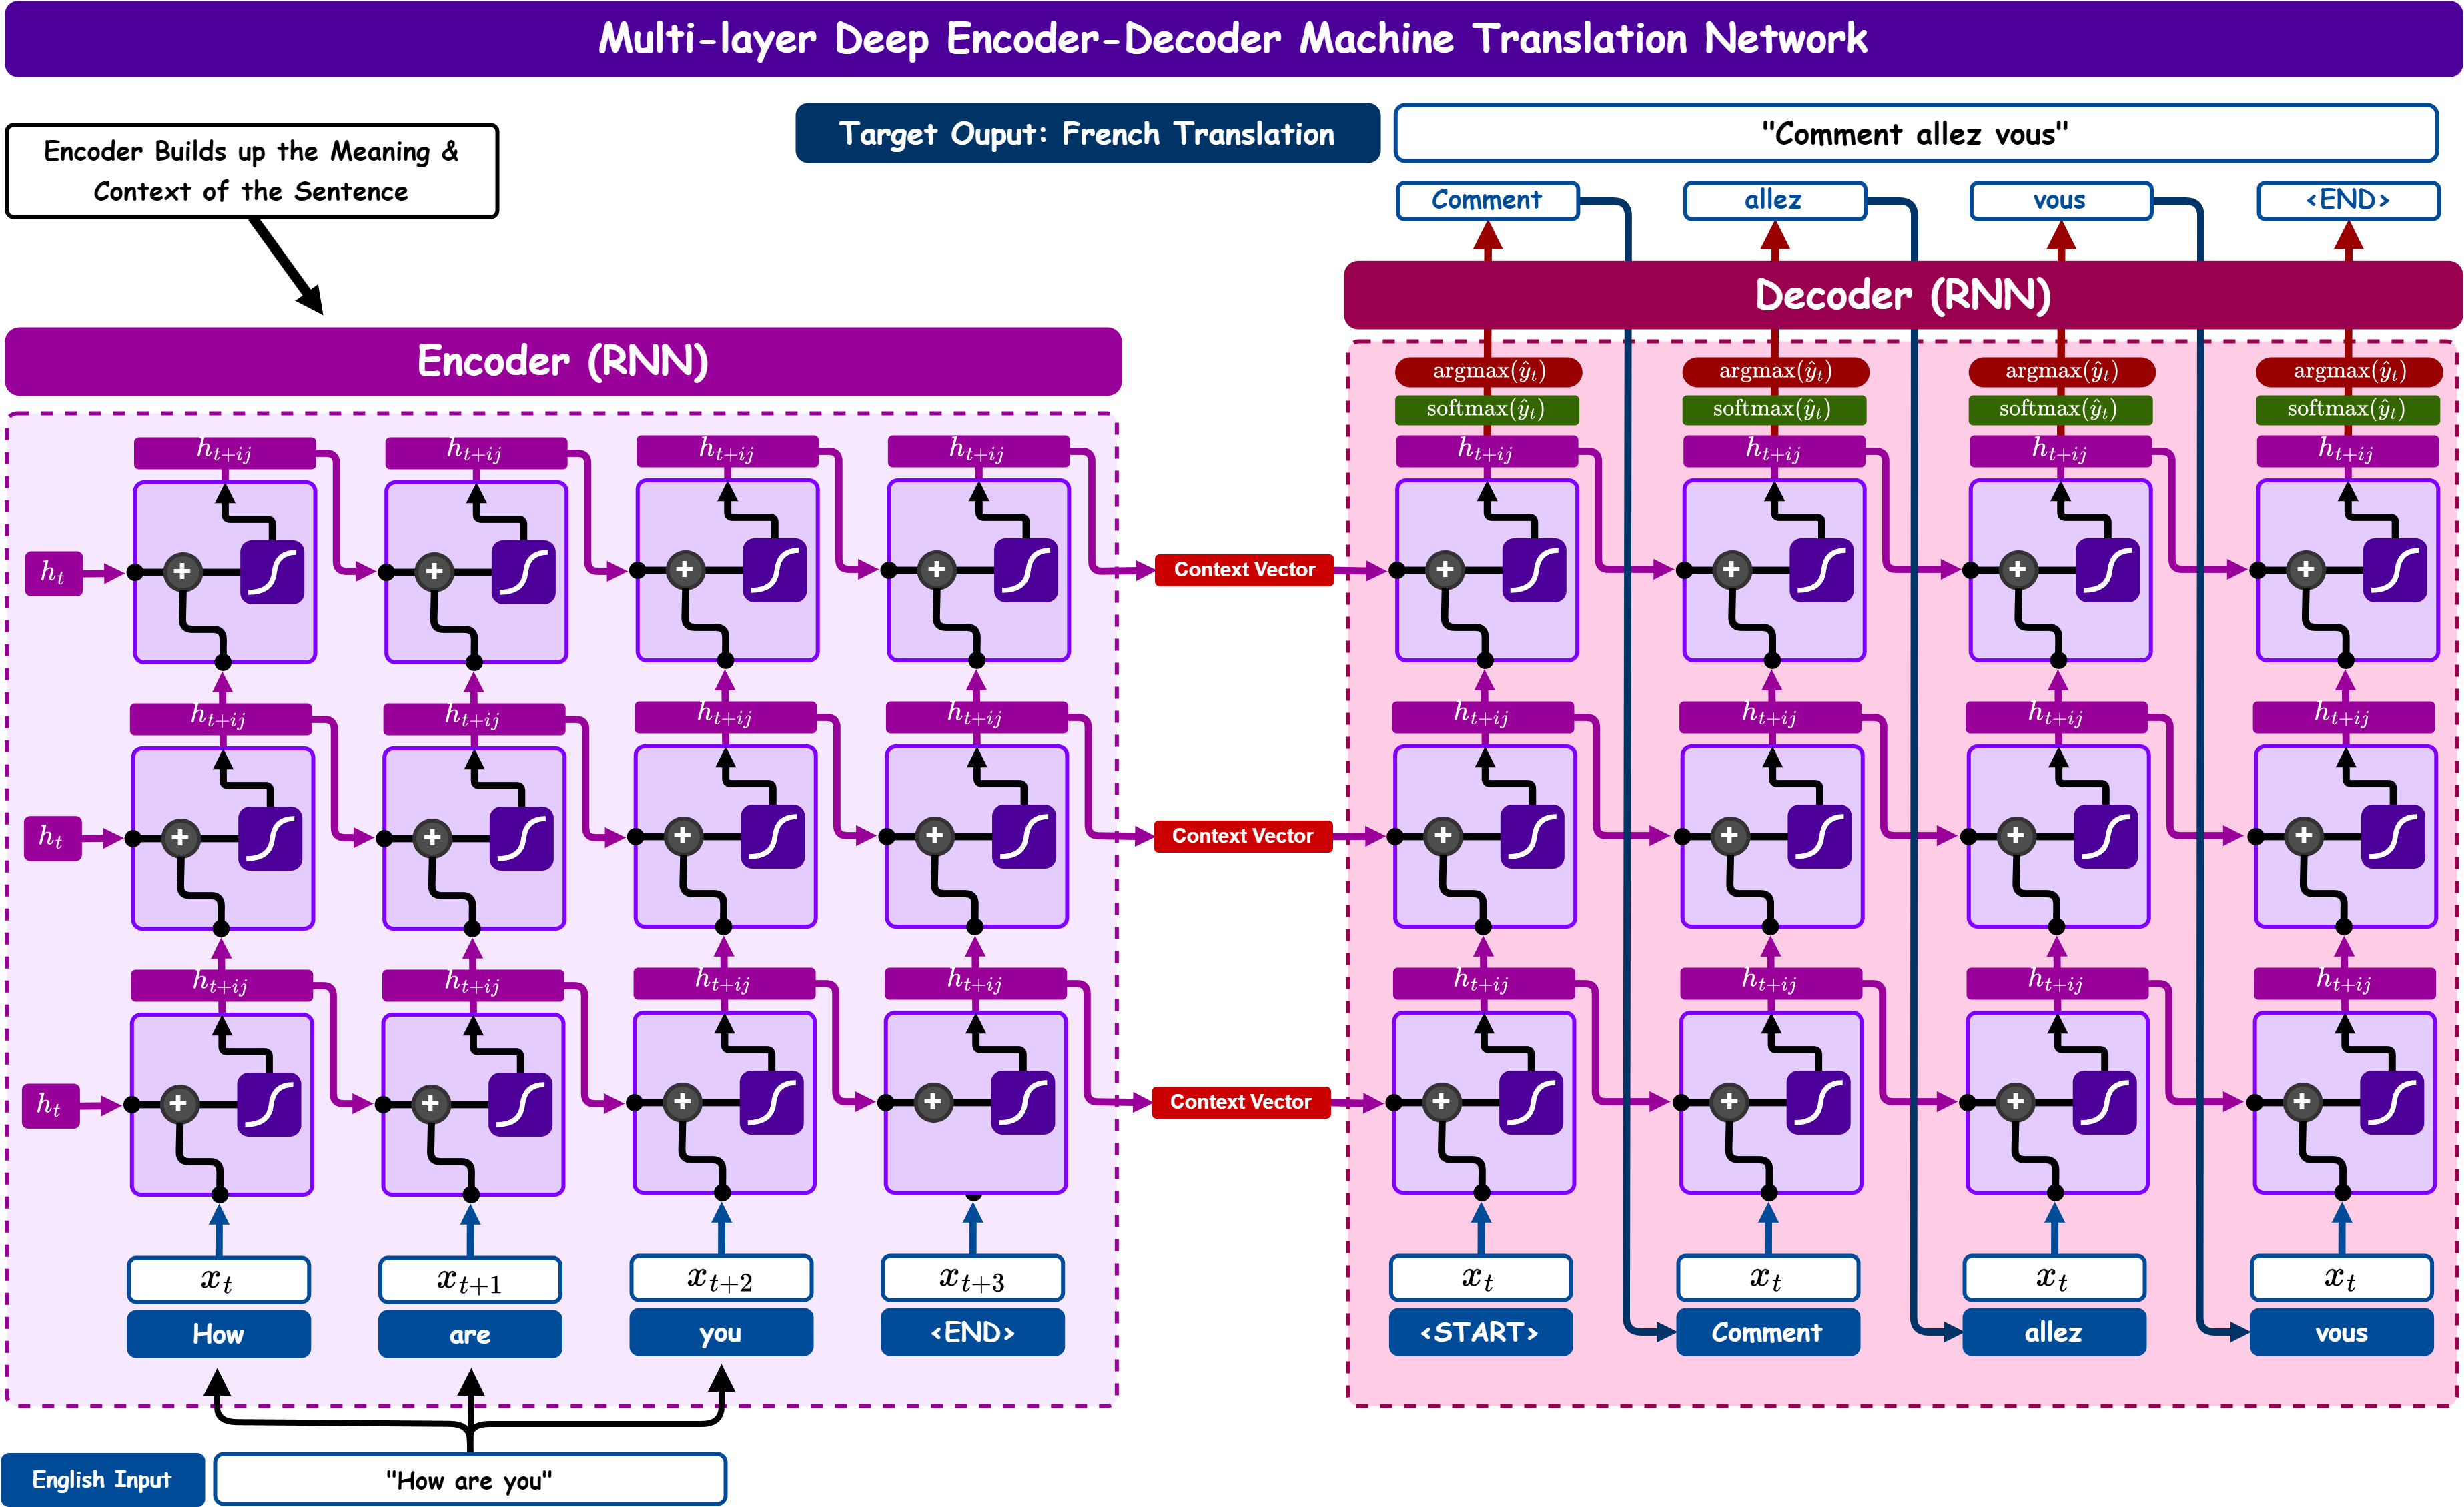

<br>

### **Training: Neural Machine Translation**

To train an NMT system you need a large **parallel corpus** a dataset of sentence pairs where each source sentence is paired with its correct translation. The model learns to maximise $P(y|x)$ across all sentence pairs in the corpus using the same cross-entropy loss and backpropagation seen in earlier sections.

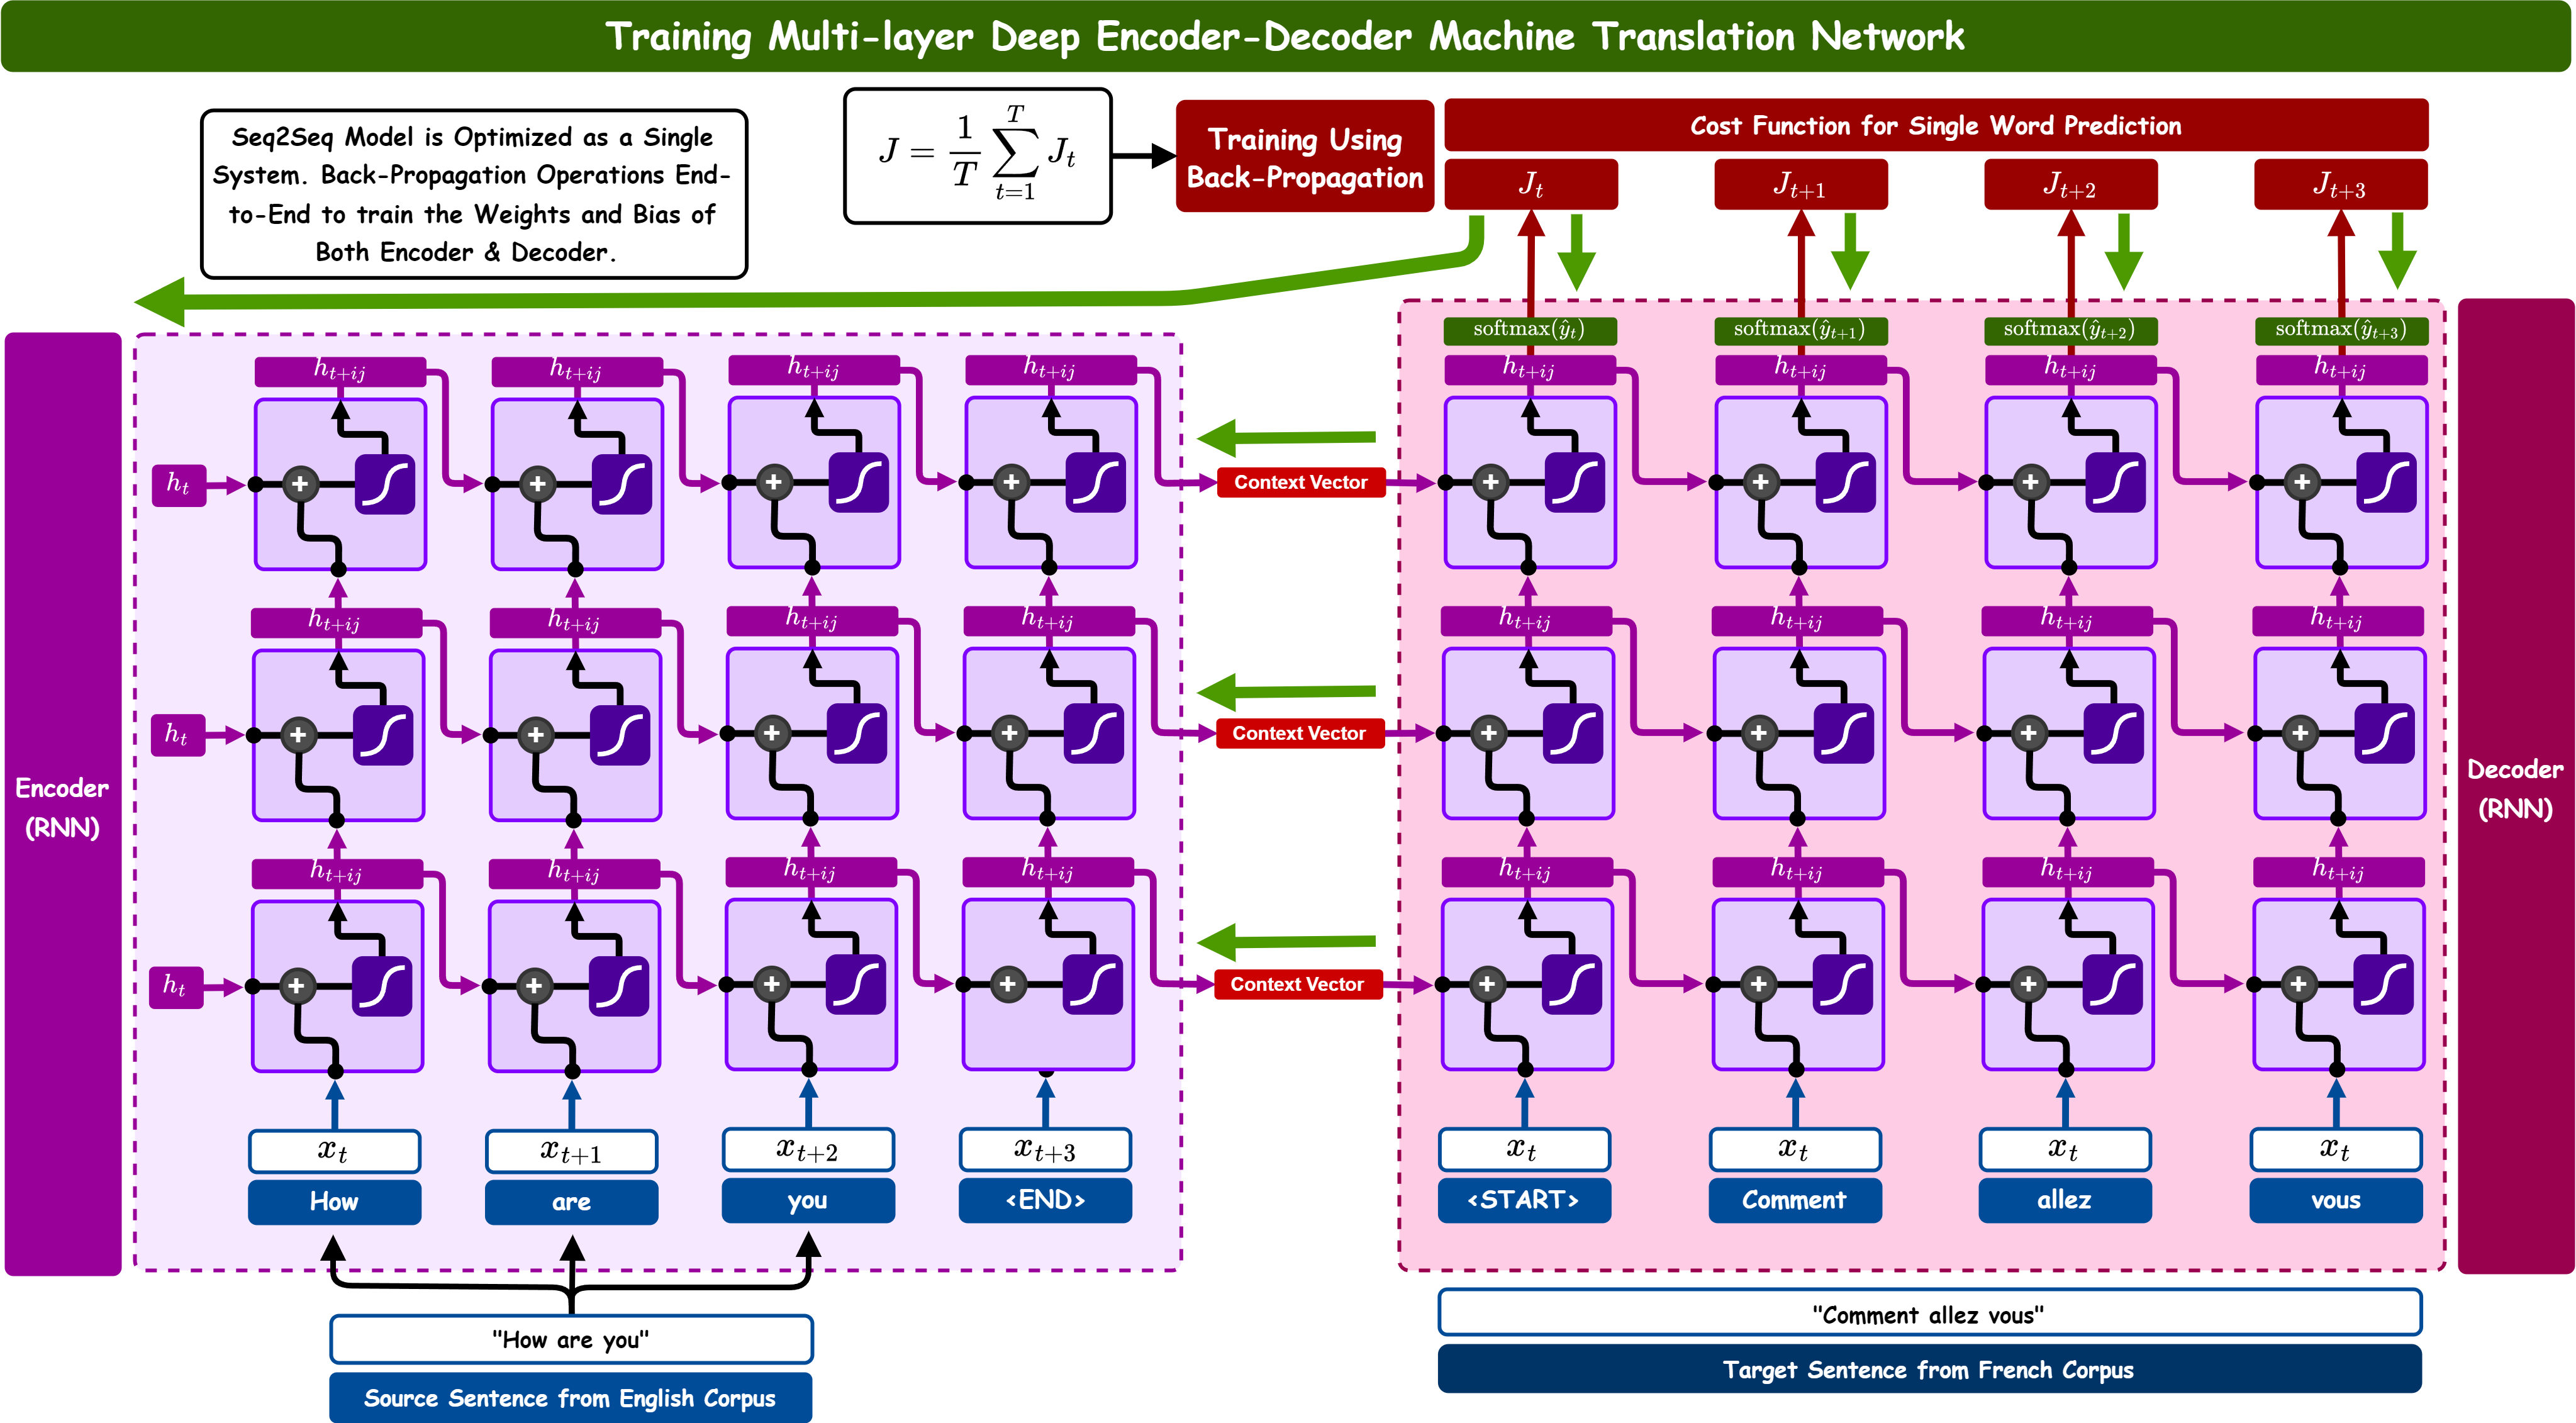

---

### **Decoding**

### **1. Greedy Decoding**

**What is greedy decoding?**

In neural machine translation, we generate the target sentence by selecting the most probable word at each timestep of the decoder. This approach is called **greedy decoding** — we take the highest-probability word (argmax) at every step.

**Example:** Translating French to English
- Input: *il a m'entarté*
- At each step: `<START>` → he → hit → me → with → a → pie → `<END>`

**The core problem:**

Greedy decoding has no mechanism to undo past decisions. Once a word is chosen, we're locked into that path — even if it leads to an incorrect or unnatural translation.

**Example of failure:**
- Correct: *he hit me with a pie*
- Greedy: *he hit **a*** (wrong choice — no way to backtrack)

<br>

### **2. Exhaustive Search Decoding**

**Goal:** Find the translation sequence $y$ of length $T$ that maximizes:

$$P(y|x) = P(y_1|x)P(y_2|y_1,x)P(y_3|y_1,y_2,x) \dots P(y_T|y_1,y_2,\dots,y_{T-1},x)$$

$$= \prod_{t=1}^{T} P(y_t|y_1,y_2,\dots,y_{t-1},x)$$

Where:
- $y$ = the complete target sequence
- $x$ = the source input
- $T$ = length of the translation
- $P(y_t|y_1,\dots,y_{t-1},x)$ = probability of word $y_t$ given all previous words and the source

**Why we can't use this:**

We could try computing probabilities for **all possible sequences**, but at each timestep $t$, we'd be tracking $V^t$ partial translations (where $V$ is vocabulary size). This has $O(V^T)$ complexity — computationally impossible for realistic vocabulary sizes.

<br>

### **3. Beam Search Decoding**

**Core idea:** At each decoder step, maintain the $k$ most probable partial translations (called **hypotheses**).

- $k$ is the **beam size** (typically 5–10 in practice)
- We don't explore all possibilities, just the top $k$ at each step

**Scoring hypotheses:**

Each hypothesis $y_1, \dots, y_t$ has a score equal to its log probability:

$$\text{score}(y_1,y_2,\dots,y_t) = \log P(y_1,y_2,\dots,y_t|x) = \sum_{i=1}^{t} \log P(y_i|y_1,y_2,\dots,y_{i-1},x)$$

**Why log probabilities?**
- Scores are all negative; higher (closer to zero) is better
- Adding logs is computationally stable and avoids underflow

**Key properties:**
- Beam search is **not guaranteed** to find the optimal solution
- But it's **far more efficient** than exhaustive search
- Explores a reasonable middle ground between greedy and exhaustive

<br>

### **4. Beam Search Example (Step-by-Step)**

**Setup:** Beam size $k = 2$, translating to English

**Notation:** Blue numbers show cumulative scores:

$$\text{score}(y_1,y_2,\dots,y_t) = \sum_{i=1}^{t} \log P(y_i|y_1,y_2,\dots,y_{i-1},x)$$

#### **Step 1: Initial word selection**

From `<START>`, compute probabilities for all possible first words. Keep top $k=2$:

| Hypothesis | Score |
|------------|-------|
| he | -0.7 |
| I | -0.9 |

#### **Step 2: Expand each hypothesis**

For each of the 2 current hypotheses, find the top $k$ next words and compute new scores:

| Previous | Next word | Score calculation | New score |
|----------|-----------|-------------------|-----------|
| he | hit | $\log P(\text{hit}\|\text{<START> he}) + (-0.7)$ | -1.7 |
| he | struck | $\log P(\text{struck}\|\text{<START> he}) + (-0.7)$ | -2.9 |
| I | was | $\log P(\text{was}\|\text{<START> I}) + (-0.9)$ | -1.6 |
| I | got | $\log P(\text{got}\|\text{<START> I}) + (-0.9)$ | -1.8 |

We now have $k^2 = 4$ candidates. **Keep only top $k=2$:**

| Hypothesis | Score |
|------------|-------|
| I was | -1.6 |
| he hit | -1.7 |

#### **Step 3: Continue expansion**

For "he hit" and "I was", find top $k$ continuations:

| Previous | Next word | New score |
|----------|-----------|-----------|
| he hit | me | -2.5 |
| he hit | a | -2.8 |
| I was | hit | -2.9 |
| I was | struck | -3.8 |

**Keep top 2:** "he hit me" (-2.5) and "he hit a" (-2.8)

#### **Step 4: Continue until completion**

Process continues. At each step:
1. Expand each of the $k$ hypotheses by considering top $k$ next words
2. Rank all $k^2$ candidates by score
3. Keep only the top $k$

**Final result:** "he hit me with a pie" emerges as the top-scoring complete hypothesis.

<br>

### **5. Beam Search — Stopping Criterion**

**In greedy decoding:** Stop when the model produces `<END>`

**In beam search:** Different hypotheses may produce `<END>` at different timesteps.

**Procedure:**
1. When a hypothesis generates `<END>`, mark it as **complete**
2. Set it aside and continue exploring other active hypotheses

**Typical stopping conditions (use one or both):**
- Reach a maximum timestep $T$ (pre-defined cutoff)
- Accumulate at least $n$ completed hypotheses (pre-defined threshold)

**Final selection:** Once stopped, select the completed hypothesis with the highest score.

<br>

### **6. Choosing Beam Size $k$**

**Small $k$ (e.g., $k=1$):**
- Equivalent to greedy decoding
- Fast but produces low-quality output
- Common issues: ungrammatical, unnatural, nonsensical, or incorrect translations

**Larger $k$ (e.g., $k=5$ to $k=10$):**
- Explores more hypotheses
- Reduces problems seen with greedy decoding
- Improves translation quality
- Trade-off: higher computational cost

**Finding the right balance:** Typical practice uses $k$ between 5 and 10 — large enough to improve quality without excessive computation.

<br>

### **7. Beam Search — Length Normalization**

**Problem:** Raw log probability scores penalize longer sequences.

Each hypothesis $y_1, \dots, y_t$ has score:

$$\text{score}(y_1,y_2,\dots,y_t) = \log P(y_1,y_2,\dots,y_t|x) = \sum_{i=1}^{t} \log P(y_i|y_1,y_2,\dots,y_{i-1},x)$$

Since log probabilities are negative, longer sequences accumulate more negative terms and get lower scores — even if they're better translations.

**Solution:** Normalize by length before selecting the best hypothesis:

$$\text{normalized score} = \frac{1}{t} \sum_{i=1}^{t} \log P(y_i|y_1,y_2,\dots,y_{i-1},x)$$

This gives a fair comparison between hypotheses of different lengths.

<br>

### **8. Alternative Decoding Methods**

Beyond greedy and beam search, other approaches offer different trade-offs:

**Sampling methods** — introduce diversity and randomness:
- Useful for **creative generation** tasks (poetry, stories, open-ended text)
- Instead of always picking the most probable word, randomly sample from high-probability options

**Top-$n$ sampling:**
- At each step, randomly sample a word from the **top-$n$ most probable words**
- Controls diversity — higher $n$ = more variety

**Top-$p$ sampling (nucleus sampling):**
- At each step, randomly sample from the **top-$p$ proportion** of the probability mass
- Example: if $p = 0.9$, sample from the smallest set of words whose cumulative probability ≥ 90%
- Adapts to the uncertainty at each step

### **Decoding Methods Comparison**

| Method | How It Works | Parameter | Speed | Quality | Diversity | Used By (Examples) |
|--------|--------------|-----------|-------|---------|-----------|-------------------|
| **Greedy** | Pick highest probability word each step | k = 1 | Fastest | Low | None | Early NMT systems (2014-2016), baselines |
| **Beam Search** | Keep top k hypotheses each step | k = 5-10 | Moderate | High | Low | Google Translate (2016+), DeepL, most NMT systems (2017-present) |
| **Top-n Sampling** | Sample from top n probable words | n = 10-50 | Moderate | Medium | High | GPT-2 (2019), early text generation |
| **Top-p Sampling** | Sample from top p% probability mass | p = 0.9-0.95 | Moderate | High | Medium | GPT-3 (2020), GPT-4 (2023), Claude (2023+), most modern LLMs |

**Current trends (2023-2024):**
- Translation/Summarization: Beam search remains standard
- Chat/Creative: Top-p sampling + temperature control is default
- Emerging: Speculative decoding, contrastive decoding for speed/quality improvements